# 05 - Riconoscimento immagini con CNN su CIFAR-10

In questo progetto costruiamo un sistema di **multiclass image classification** con **Convolutional Neural Networks**
usando il dataset **CIFAR-10** caricato **solo dai file locali** nella cartella `cifar-10-batches-py`.

Domande di ricerca:

1. Che accuratezza puo' raggiungere una CNN semplice con 2 blocchi convoluzionali?
2. Quanto migliorano BatchNormalization, Dropout e data augmentation?
3. E' possibile superare `85%` di test accuracy senza transfer learning?

Metriche richieste:

- Accuracy
- Macro F1-score
- Precision e recall per classe
- Confusion matrix

## Nota tecnica

Questo notebook:

- **non** scarica CIFAR-10 da internet
- carica i batch Python originali con `pickle`
- ricostruisce le immagini da vettori di lunghezza `3072`
- usa `batches.meta` per recuperare i nomi delle classi

Inoltre, nel contesto di questa macchina, TensorFlow viene eseguito con un interprete Python 3.13 dedicato.

In [1]:
import os
from pathlib import Path

# In questo ambiente di esecuzione TensorFlow richiede una cartella temporanea esplicita.
TMP_DIR = Path.cwd() / "artifacts" / "tmp_py313"
TMP_DIR.mkdir(parents=True, exist_ok=True)
os.environ["TEMP"] = str(TMP_DIR.resolve())
os.environ["TMP"] = str(TMP_DIR.resolve())
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import pickle
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from tensorflow.keras import callbacks, layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
tf.get_logger().setLevel("ERROR")

ROOT = Path.cwd()
DATA_DIR = ROOT / "cifar-10-batches-py"
ARTIFACTS_DIR = ROOT / "artifacts"
ARTIFACTS_DIR.mkdir(exist_ok=True)

print("TensorFlow version:", tf.__version__)
print("Dispositivi disponibili:", tf.config.list_physical_devices())

TensorFlow version: 2.21.0
Dispositivi disponibili: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [2]:
def load_pickle_file(path):
    with open(path, "rb") as file:
        return pickle.load(file, encoding="bytes")

def reconstruct_images(flat_data):
    # Il formato CIFAR-10 salva ogni immagine come [1024 R | 1024 G | 1024 B].
    images = flat_data.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    return images

def load_cifar_batch(path):
    batch = load_pickle_file(path)
    images = reconstruct_images(batch[b"data"])
    labels = np.array(batch[b"labels"])
    return images, labels

def load_cifar10_local(data_dir):
    meta = load_pickle_file(data_dir / "batches.meta")
    class_names = [label.decode("utf-8") for label in meta[b"label_names"]]

    train_images = []
    train_labels = []
    for batch_id in range(1, 6):
        images, labels = load_cifar_batch(data_dir / f"data_batch_{batch_id}")
        train_images.append(images)
        train_labels.append(labels)

    x_train_full_uint8 = np.concatenate(train_images, axis=0)
    y_train_full_int = np.concatenate(train_labels, axis=0)
    x_test_uint8, y_test_int = load_cifar_batch(data_dir / "test_batch")

    return x_train_full_uint8, y_train_full_int, x_test_uint8, y_test_int, class_names

x_train_full_uint8, y_train_full_int, x_test_uint8, y_test_int, class_names = load_cifar10_local(DATA_DIR)
num_classes = len(class_names)

print("Training set shape:", x_train_full_uint8.shape)
print("Test set shape:", x_test_uint8.shape)
print("Numero classi:", num_classes)
print("Class names:", class_names)

Training set shape: (50000, 32, 32, 3)
Test set shape: (10000, 32, 32, 3)
Numero classi: 10
Class names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 1. EDA

Analizziamo il dataset con:

- griglia di immagini campione
- distribuzione delle classi
- statistiche di base dei pixel
- immagine media per classe

,class_id,class_name,count
0,0,airplane,5000
1,1,automobile,5000
2,2,bird,5000
3,3,cat,5000
4,4,deer,5000
5,5,dog,5000
6,6,frog,5000
7,7,horse,5000
8,8,ship,5000
9,9,truck,5000


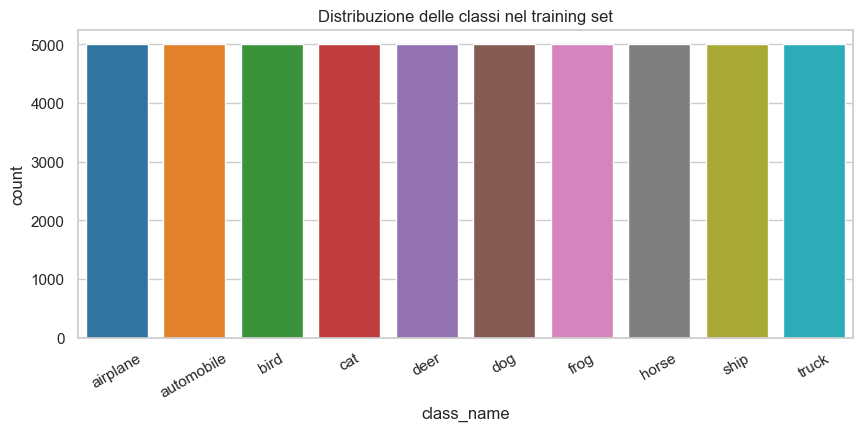

In [3]:
train_distribution = pd.Series(y_train_full_int).value_counts().sort_index()
distribution_df = pd.DataFrame(
    {
        "class_id": range(num_classes),
        "class_name": class_names,
        "count": train_distribution.values,
    }
)
display(distribution_df)

plt.figure(figsize=(10, 4))
sns.barplot(data=distribution_df, x="class_name", y="count", palette="tab10")
plt.title("Distribuzione delle classi nel training set")
plt.xticks(rotation=30)
plt.show()

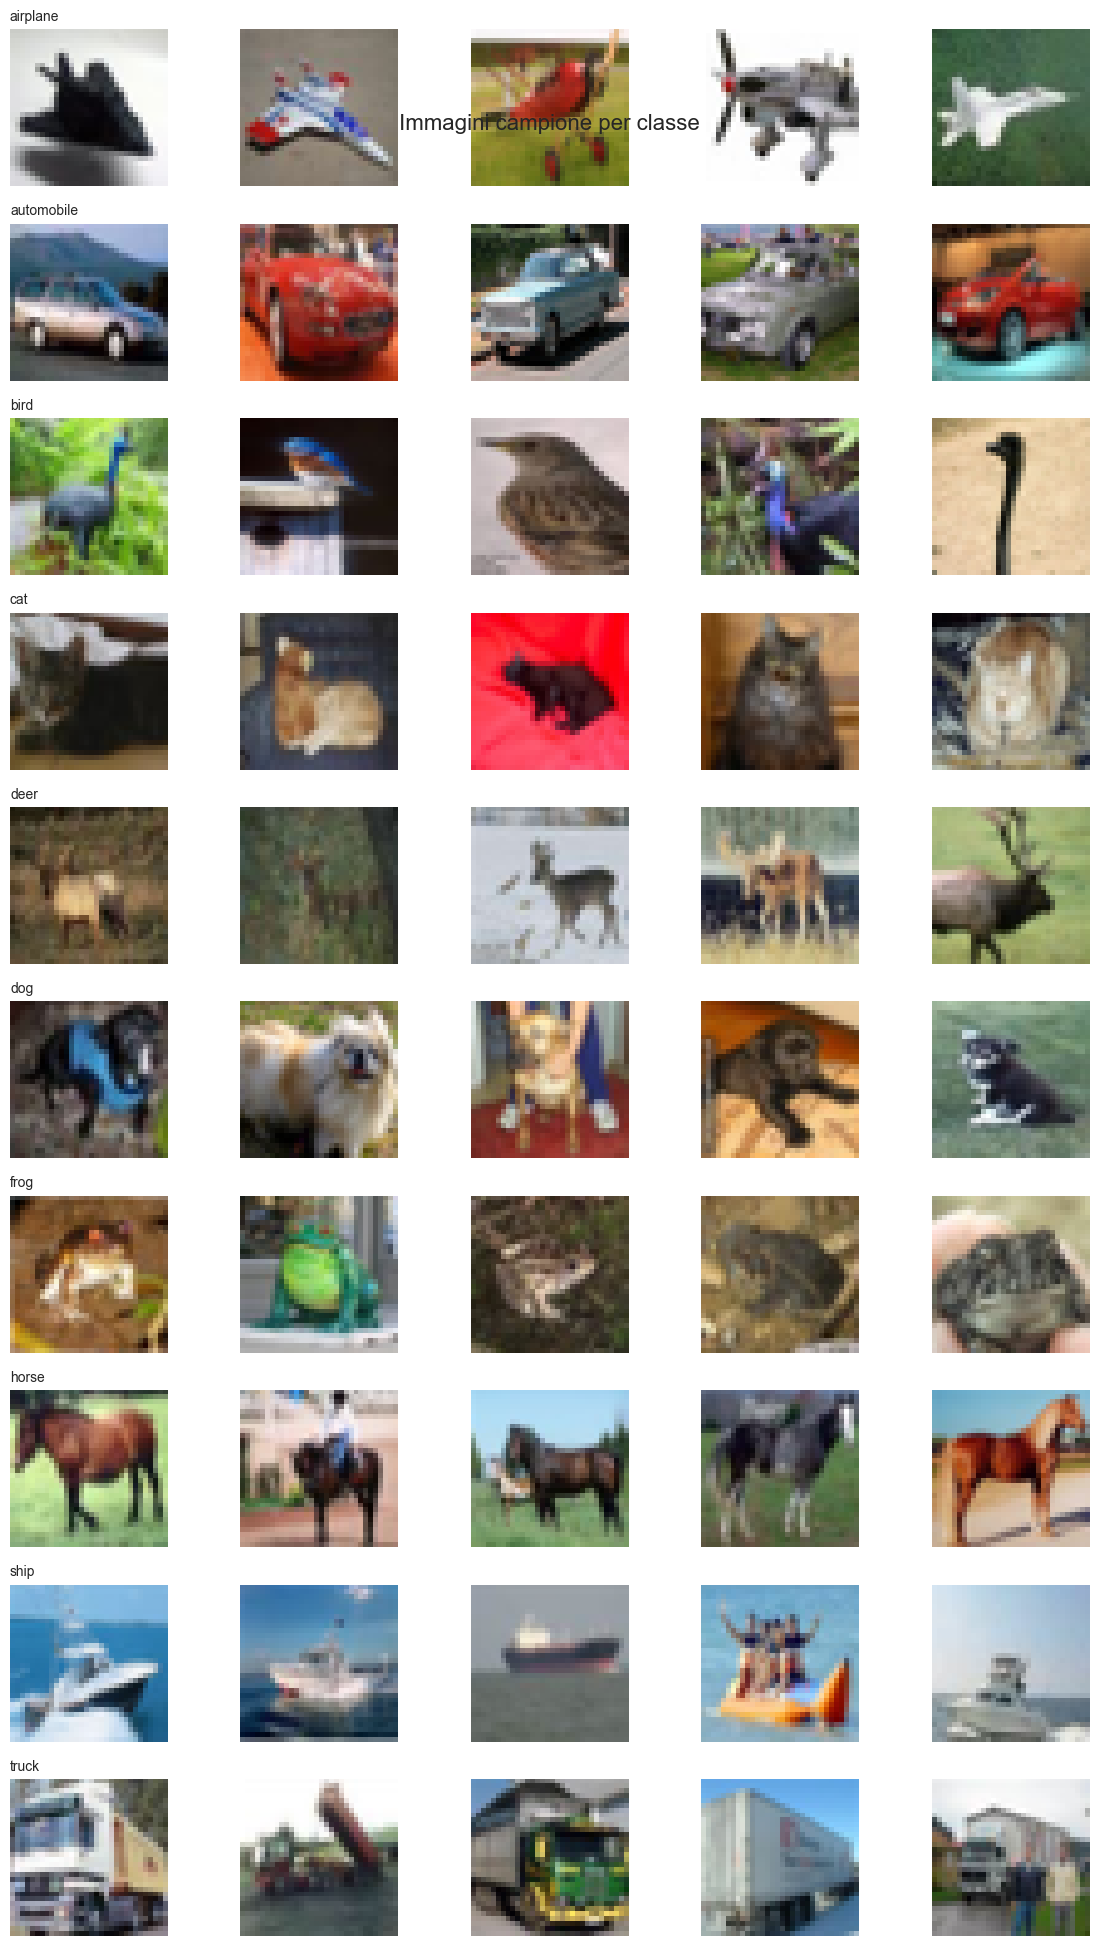

In [4]:
samples_per_class = 5
fig, axes = plt.subplots(num_classes, samples_per_class, figsize=(12, 20))

for class_id, class_name in enumerate(class_names):
    class_indices = np.where(y_train_full_int == class_id)[0][:samples_per_class]
    for col_idx, image_index in enumerate(class_indices):
        axes[class_id, col_idx].imshow(x_train_full_uint8[image_index])
        axes[class_id, col_idx].axis("off")
        if col_idx == 0:
            axes[class_id, col_idx].set_title(class_name, loc="left", fontsize=10)

plt.suptitle("Immagini campione per classe", y=0.92, fontsize=16)
plt.tight_layout()
plt.show()

In [5]:
overall_pixel_stats = pd.DataFrame(
    {
        "metric": ["min", "max", "mean", "std"],
        "value": [
            float(x_train_full_uint8.min()),
            float(x_train_full_uint8.max()),
            float(x_train_full_uint8.mean()),
            float(x_train_full_uint8.std()),
        ],
    }
)

channel_stats = pd.DataFrame(
    {
        "channel": ["red", "green", "blue"],
        "mean": x_train_full_uint8.mean(axis=(0, 1, 2)),
        "std": x_train_full_uint8.std(axis=(0, 1, 2)),
    }
)

print("Statistiche globali dei pixel:")
display(overall_pixel_stats)
print("Statistiche per canale:")
display(channel_stats.round(2))

Statistiche globali dei pixel:


,metric,value
0,min,0.000000
1,max,255.000000
2,mean,120.707565
3,std,64.150076


Statistiche per canale:


,channel,mean,std
0,red,125.31,62.99
1,green,122.95,62.09
2,blue,113.87,66.70


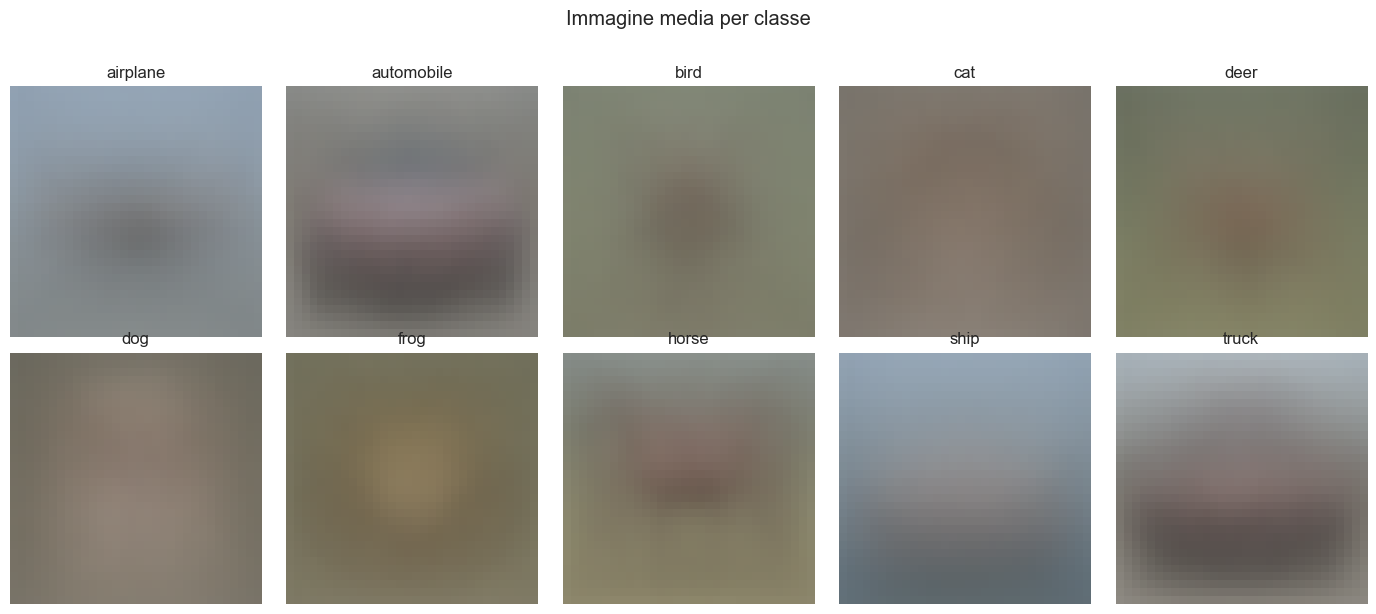

In [6]:
average_images = []
for class_id in range(num_classes):
    class_mean_image = x_train_full_uint8[y_train_full_int == class_id].mean(axis=0).astype(np.uint8)
    average_images.append(class_mean_image)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for class_id, ax in enumerate(axes.flatten()):
    ax.imshow(average_images[class_id])
    ax.set_title(class_names[class_id])
    ax.axis("off")
plt.suptitle("Immagine media per classe", y=1.02)
plt.tight_layout()
plt.show()

## 2. Preprocessing

Passi richiesti:

- concatenazione dei 5 training batch
- validation split stratificato
- conversione in `float32`
- normalizzazione con `x / 255.0`
- one-hot encoding delle etichette
- preparazione del `ImageDataGenerator`

In [7]:
x_train_uint8, x_val_uint8, y_train_int, y_val_int = train_test_split(
    x_train_full_uint8,
    y_train_full_int,
    test_size=5000,
    stratify=y_train_full_int,
    random_state=SEED,
)

x_train = x_train_uint8.astype("float32") / 255.0
x_val = x_val_uint8.astype("float32") / 255.0
x_test = x_test_uint8.astype("float32") / 255.0

y_train = to_categorical(y_train_int, num_classes=num_classes)
y_val = to_categorical(y_val_int, num_classes=num_classes)
y_test = to_categorical(y_test_int, num_classes=num_classes)

augmentation_generator = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True,
    fill_mode="nearest",
)

split_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "shape": [x_train.shape, x_val.shape, x_test.shape],
        "num_samples": [len(x_train), len(x_val), len(x_test)],
    }
)
display(split_summary)

print("x_train dtype:", x_train.dtype)
print("Range dopo la normalizzazione:", float(x_train.min()), "->", float(x_train.max()))

,split,shape,num_samples
0,train,"(45000, 32, 32, 3)",45000
1,validation,"(5000, 32, 32, 3)",5000
2,test,"(10000, 32, 32, 3)",10000


x_train dtype: float32
Range dopo la normalizzazione: 0.0 -> 1.0


## 3. Modeling

Confrontiamo tre architetture:

- **A. Baseline CNN** con 2 blocchi convoluzionali
- **B. Improved CNN** con BatchNormalization e Dropout
- **C. Improved CNN + Data Augmentation**

In [8]:
def build_baseline_cnn(input_shape=(32, 32, 3), num_classes=10):
    model = models.Sequential(
        [
            layers.Input(shape=input_shape),
            layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
            layers.MaxPooling2D(pool_size=(2, 2)),
            layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
            layers.MaxPooling2D(pool_size=(2, 2)),
            layers.Flatten(),
            layers.Dense(128, activation="relu"),
            layers.Dense(num_classes, activation="softmax"),
        ]
    )
    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

def build_improved_cnn(input_shape=(32, 32, 3), num_classes=10):
    inputs = layers.Input(shape=input_shape)
    x = inputs

    for filters, dropout_rate in [(32, 0.20), (64, 0.30), (128, 0.40)]:
        x = layers.Conv2D(filters, (3, 3), padding="same", use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        x = layers.Conv2D(filters, (3, 3), padding="same", use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        x = layers.MaxPooling2D(pool_size=(2, 2))(x)
        x = layers.Dropout(dropout_rate)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(256, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(0.50)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

def make_callbacks():
    return [
        callbacks.EarlyStopping(
            monitor="val_loss",
            patience=6,
            restore_best_weights=True,
        ),
        callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=3,
            min_lr=1e-5,
            verbose=1,
        ),
    ]

baseline_model = build_baseline_cnn(num_classes=num_classes)
improved_model = build_improved_cnn(num_classes=num_classes)

print("Baseline CNN:")
baseline_model.summary()
print("\nImproved CNN:")
improved_model.summary()

Baseline CNN:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

...

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 128)      │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 816,234 (3.11 MB)

 Trainable params: 814,826 (3.11 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [9]:
BATCH_SIZE = 128
BASELINE_EPOCHS = 15
IMPROVED_EPOCHS = 25
AUGMENTED_EPOCHS = 30

baseline_model = build_baseline_cnn(num_classes=num_classes)
history_baseline = baseline_model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=BASELINE_EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=2,
)

Epoch 1/15


352/352 - 7s - 19ms/step - accuracy: 0.4660 - loss: 1.5022 - val_accuracy: 0.5562 - val_loss: 1.2578


Epoch 2/15


352/352 - 5s - 15ms/step - accuracy: 0.6002 - loss: 1.1397 - val_accuracy: 0.6324 - val_loss: 1.0517


Epoch 3/15


...

352/352 - 7s - 19ms/step - accuracy: 0.8295 - loss: 0.4977 - val_accuracy: 0.7090 - val_loss: 0.9699


Epoch 14/15


352/352 - 7s - 19ms/step - accuracy: 0.8375 - loss: 0.4670 - val_accuracy: 0.7170 - val_loss: 0.9177


Epoch 15/15


352/352 - 7s - 20ms/step - accuracy: 0.8508 - loss: 0.4333 - val_accuracy: 0.6988 - val_loss: 0.9884


In [10]:
improved_model = build_improved_cnn(num_classes=num_classes)
history_improved = improved_model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=IMPROVED_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=make_callbacks(),
    verbose=2,
)

Epoch 1/25


352/352 - 53s - 150ms/step - accuracy: 0.4185 - loss: 1.6363 - val_accuracy: 0.2394 - val_loss: 2.4398 - learning_rate: 0.0010


Epoch 2/25


352/352 - 45s - 128ms/step - accuracy: 0.5901 - loss: 1.1394 - val_accuracy: 0.5686 - val_loss: 1.2326 - learning_rate: 0.0010


Epoch 3/25


...

352/352 - 45s - 128ms/step - accuracy: 0.9005 - loss: 0.2790 - val_accuracy: 0.8704 - val_loss: 0.3975 - learning_rate: 2.5000e-04


Epoch 24/25


352/352 - 45s - 127ms/step - accuracy: 0.9054 - loss: 0.2663 - val_accuracy: 0.8702 - val_loss: 0.3956 - learning_rate: 2.5000e-04


Epoch 25/25


352/352 - 45s - 128ms/step - accuracy: 0.9075 - loss: 0.2589 - val_accuracy: 0.8680 - val_loss: 0.4000 - learning_rate: 2.5000e-04


In [11]:
augmented_model = build_improved_cnn(num_classes=num_classes)
augmentation_flow = augmentation_generator.flow(
    x_train,
    y_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

history_augmented = augmented_model.fit(
    augmentation_flow,
    validation_data=(x_val, y_val),
    epochs=AUGMENTED_EPOCHS,
    callbacks=make_callbacks(),
    verbose=2,
)

Epoch 1/30


352/352 - 52s - 148ms/step - accuracy: 0.3802 - loss: 1.7481 - val_accuracy: 0.2102 - val_loss: 2.6793 - learning_rate: 0.0010


Epoch 2/30


352/352 - 49s - 139ms/step - accuracy: 0.5315 - loss: 1.2955 - val_accuracy: 0.5638 - val_loss: 1.2405 - learning_rate: 0.0010


Epoch 3/30


...

Epoch 29/30


352/352 - 49s - 138ms/step - accuracy: 0.8259 - loss: 0.4999 - val_accuracy: 0.8508 - val_loss: 0.4261 - learning_rate: 6.2500e-05


Epoch 30/30



Epoch 30: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.


352/352 - 49s - 139ms/step - accuracy: 0.8266 - loss: 0.5032 - val_accuracy: 0.8524 - val_loss: 0.4296 - learning_rate: 6.2500e-05


## 4. Evaluation

Valutiamo ciascun modello con:

- performance finali train / validation / test
- summary table
- curve di training
- confusion matrix
- classification report
- analisi delle classi piu' confuse

In [12]:
def history_to_dataframe(history):
    return pd.DataFrame(history.history)

def evaluate_model(model, x_data, y_true_int, history, model_name):
    y_prob = model.predict(x_data, batch_size=BATCH_SIZE, verbose=0)
    y_pred_int = np.argmax(y_prob, axis=1)

    test_accuracy = accuracy_score(y_true_int, y_pred_int)
    macro_f1 = f1_score(y_true_int, y_pred_int, average="macro")
    precision, recall, f1_values, support = precision_recall_fscore_support(
        y_true_int,
        y_pred_int,
        labels=range(num_classes),
        zero_division=0,
    )
    confusion = confusion_matrix(y_true_int, y_pred_int)
    report_df = pd.DataFrame(
        classification_report(
            y_true_int,
            y_pred_int,
            target_names=class_names,
            output_dict=True,
            zero_division=0,
        )
    ).T

    history_df = history_to_dataframe(history)
    metrics_row = {
        "model": model_name,
        "train_accuracy_last": history_df["accuracy"].iloc[-1],
        "train_loss_last": history_df["loss"].iloc[-1],
        "best_val_accuracy": history_df["val_accuracy"].max(),
        "best_val_loss": history_df["val_loss"].min(),
        "test_accuracy": test_accuracy,
        "macro_f1": macro_f1,
    }

    per_class_df = pd.DataFrame(
        {
            "class_name": class_names,
            "precision": precision,
            "recall": recall,
            "f1_score": f1_values,
            "support": support,
        }
    )

    return {
        "metrics_row": metrics_row,
        "history_df": history_df,
        "y_pred_int": y_pred_int,
        "y_prob": y_prob,
        "confusion_matrix": confusion,
        "classification_report_df": report_df,
        "per_class_df": per_class_df,
    }

def most_confused_pairs(confusion, class_names, top_n=5):
    confusion_no_diag = confusion.copy()
    np.fill_diagonal(confusion_no_diag, 0)
    pairs = []
    for true_idx in range(confusion_no_diag.shape[0]):
        for pred_idx in range(confusion_no_diag.shape[1]):
            if true_idx != pred_idx and confusion_no_diag[true_idx, pred_idx] > 0:
                pairs.append(
                    {
                        "true_class": class_names[true_idx],
                        "predicted_class": class_names[pred_idx],
                        "count": int(confusion_no_diag[true_idx, pred_idx]),
                    }
                )
    return pd.DataFrame(pairs).sort_values("count", ascending=False).head(top_n)

histories = {
    "Baseline CNN": history_baseline,
    "Improved CNN": history_improved,
    "CNN + Data Augmentation": history_augmented,
}

trained_models = {
    "Baseline CNN": baseline_model,
    "Improved CNN": improved_model,
    "CNN + Data Augmentation": augmented_model,
}

evaluation_results = {}
summary_rows = []
for model_name, model in trained_models.items():
    result = evaluate_model(model, x_test, y_test_int, histories[model_name], model_name)
    evaluation_results[model_name] = result
    summary_rows.append(result["metrics_row"])

summary_df = pd.DataFrame(summary_rows).sort_values(
    ["test_accuracy", "macro_f1"], ascending=False
)
display(summary_df.round(4))

best_model_name = summary_df.iloc[0]["model"]
best_model = trained_models[best_model_name]
print("Miglior modello:", best_model_name)

,model,train_accuracy_last,train_loss_last,best_val_accuracy,best_val_loss,test_accuracy,macro_f1
1,Improved CNN,0.9075,0.2589,0.8704,0.3956,0.8607,0.8601
2,CNN + Data Augmentation,0.8266,0.5032,0.8528,0.4206,0.8438,0.8421
0,Baseline CNN,0.8508,0.4333,0.7170,0.8612,0.6919,0.6903


Miglior modello: Improved CNN


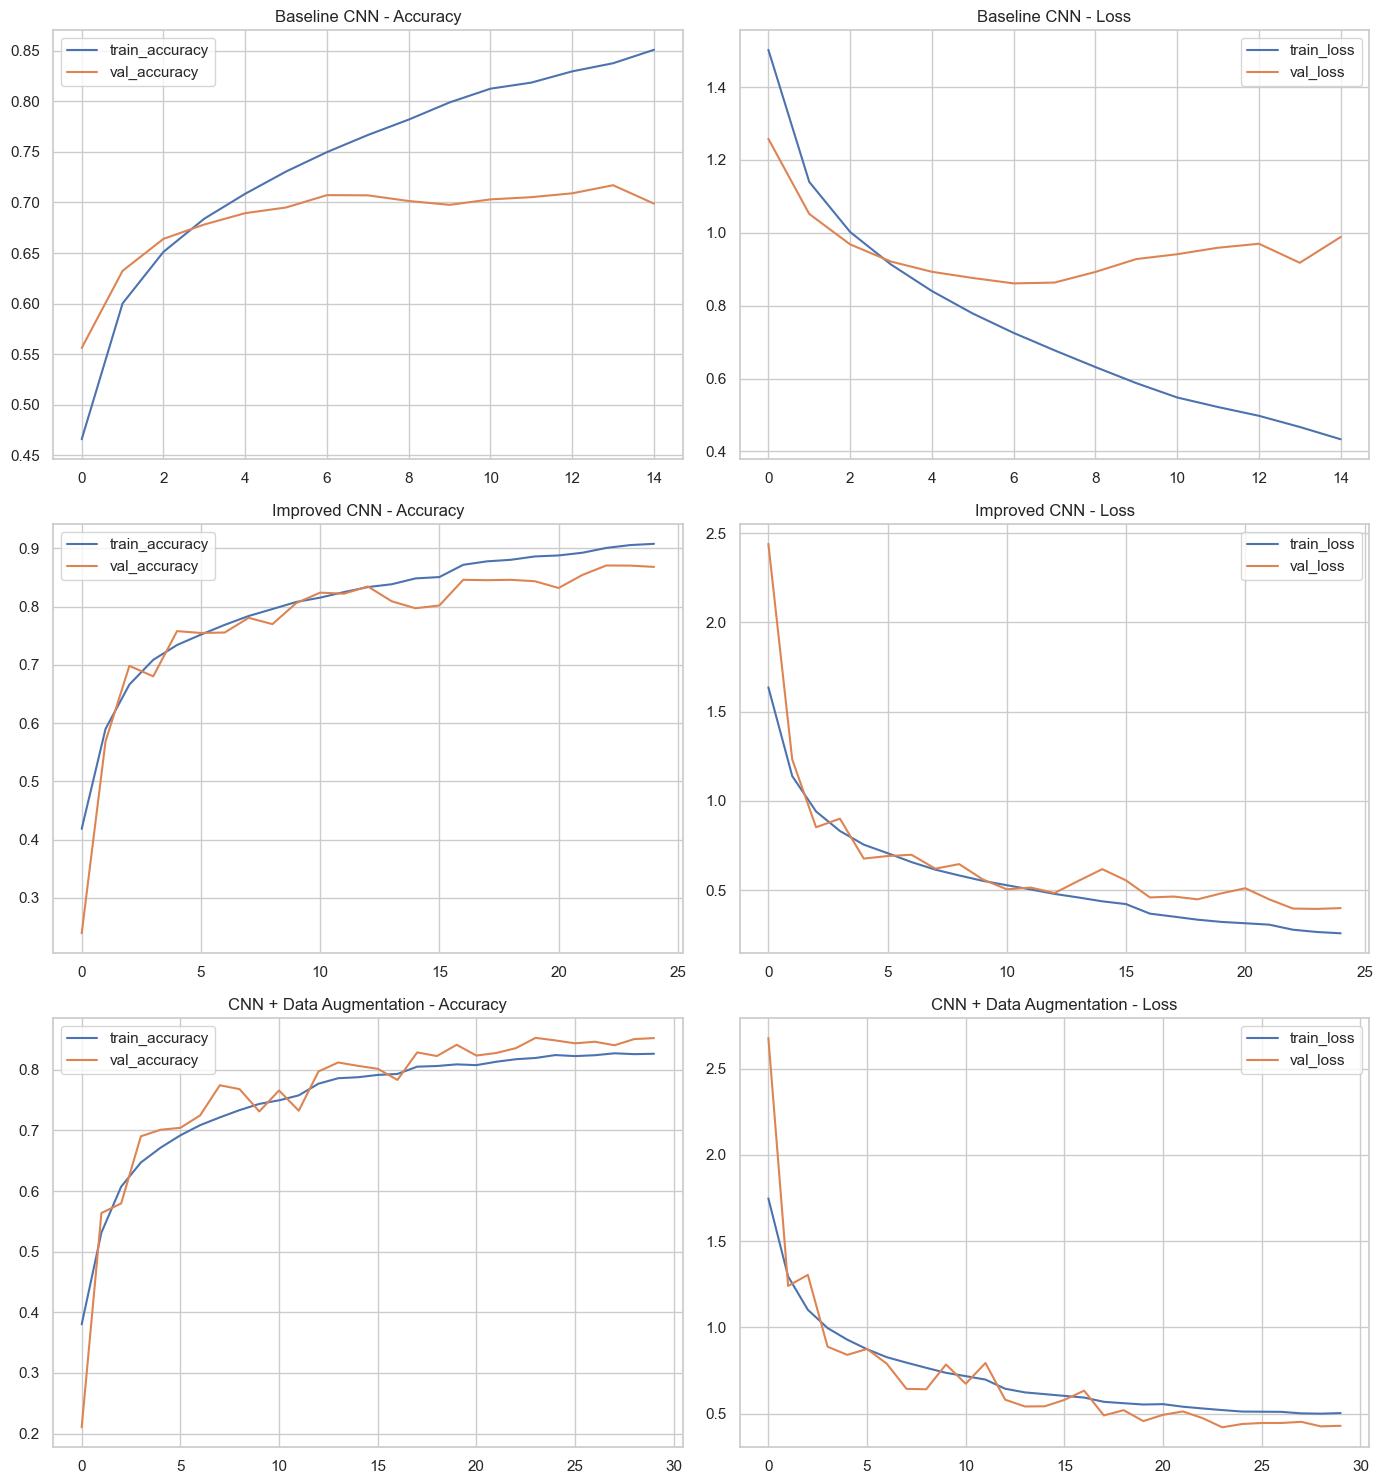

In [13]:
fig, axes = plt.subplots(3, 2, figsize=(14, 15))
for row_idx, (model_name, history) in enumerate(histories.items()):
    history_df = history_to_dataframe(history)

    axes[row_idx, 0].plot(history_df["accuracy"], label="train_accuracy")
    axes[row_idx, 0].plot(history_df["val_accuracy"], label="val_accuracy")
    axes[row_idx, 0].set_title(f"{model_name} - Accuracy")
    axes[row_idx, 0].legend()

    axes[row_idx, 1].plot(history_df["loss"], label="train_loss")
    axes[row_idx, 1].plot(history_df["val_loss"], label="val_loss")
    axes[row_idx, 1].set_title(f"{model_name} - Loss")
    axes[row_idx, 1].legend()

plt.tight_layout()
plt.show()

Baseline CNN


,precision,recall,f1-score,support
airplane,0.7218,0.7550,0.7380,1000.0000
automobile,0.7209,0.8780,0.7917,1000.0000
bird,0.5478,0.6250,0.5838,1000.0000
cat,0.5134,0.5190,0.5162,1000.0000
deer,0.7606,0.4830,0.5908,1000.0000
dog,0.6028,0.6040,0.6034,1000.0000
frog,0.7799,0.7440,0.7615,1000.0000
horse,0.6995,0.7820,0.7384,1000.0000
ship,0.8533,0.7680,0.8084,1000.0000
truck,0.7805,0.7610,0.7706,1000.0000


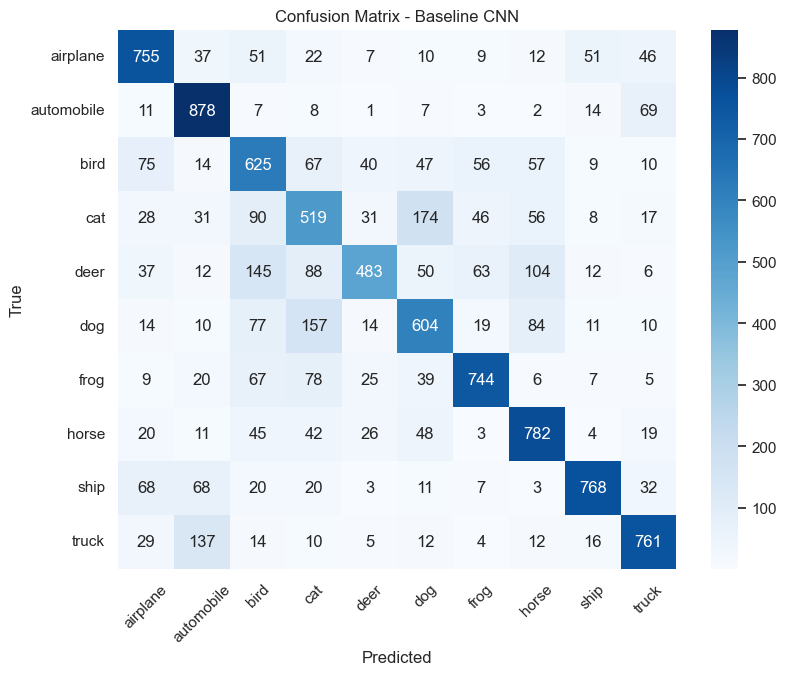

Classi piu' confuse:


,true_class,predicted_class,count
31,cat,dog,174
48,dog,cat,157
38,deer,bird,145
82,truck,automobile,137
42,deer,horse,104


Improved CNN


,precision,recall,f1-score,support
airplane,0.8285,0.9080,0.8664,1000.0000
automobile,0.9249,0.9360,0.9304,1000.0000
bird,0.8141,0.8060,0.8101,1000.0000
cat,0.7661,0.7010,0.7321,1000.0000
deer,0.8561,0.8450,0.8505,1000.0000
dog,0.7918,0.7910,0.7914,1000.0000
frog,0.8634,0.9100,0.8861,1000.0000
horse,0.9158,0.8810,0.8981,1000.0000
ship,0.9217,0.9180,0.9198,1000.0000
truck,0.9211,0.9110,0.9160,1000.0000


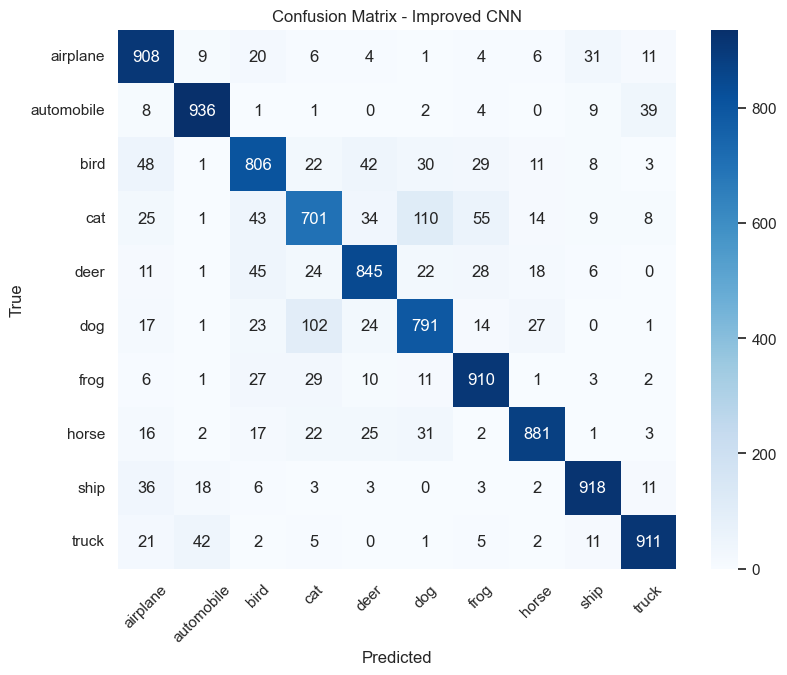

Classi piu' confuse:


,true_class,predicted_class,count
29,cat,dog,110
45,dog,cat,102
30,cat,frog,55
16,bird,airplane,48
36,deer,bird,45


CNN + Data Augmentation


,precision,recall,f1-score,support
airplane,0.8831,0.8160,0.8482,1000.0000
automobile,0.8976,0.9550,0.9254,1000.0000
bird,0.8484,0.7330,0.7865,1000.0000
cat,0.7375,0.6800,0.7076,1000.0000
deer,0.8559,0.8080,0.8313,1000.0000
dog,0.7973,0.7630,0.7798,1000.0000
frog,0.8067,0.9350,0.8661,1000.0000
horse,0.8812,0.8900,0.8856,1000.0000
ship,0.9255,0.9070,0.9162,1000.0000
truck,0.8087,0.9510,0.8741,1000.0000


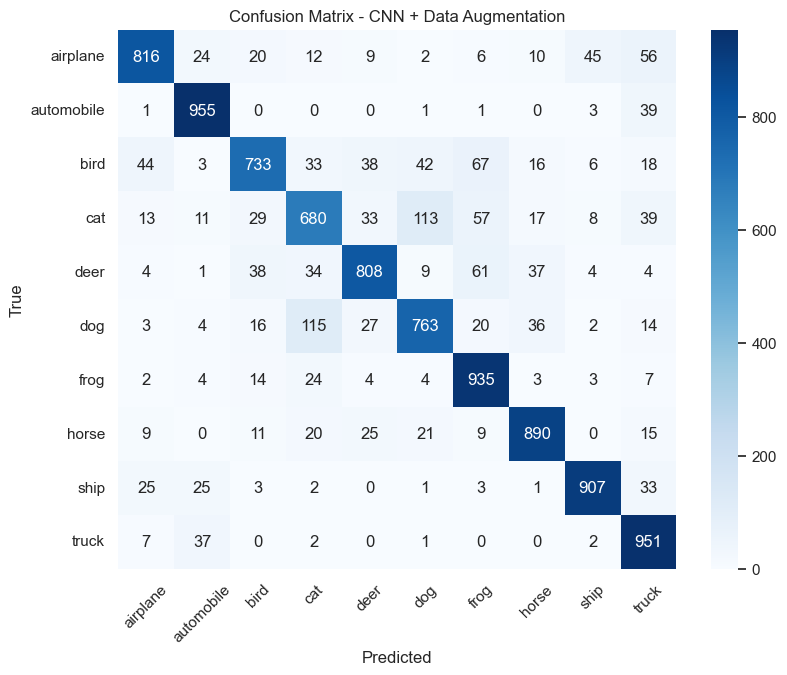

Classi piu' confuse:


,true_class,predicted_class,count
44,dog,cat,115
27,cat,dog,113
19,bird,frog,67
37,deer,frog,61
28,cat,frog,57


In [14]:
for model_name, result in evaluation_results.items():
    print("=" * 80)
    print(model_name)
    display(result["classification_report_df"].round(4))

    plt.figure(figsize=(9, 7))
    sns.heatmap(
        result["confusion_matrix"],
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
    )
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.show()

    confused_df = most_confused_pairs(result["confusion_matrix"], class_names, top_n=5)
    print("Classi piu' confuse:")
    display(confused_df)

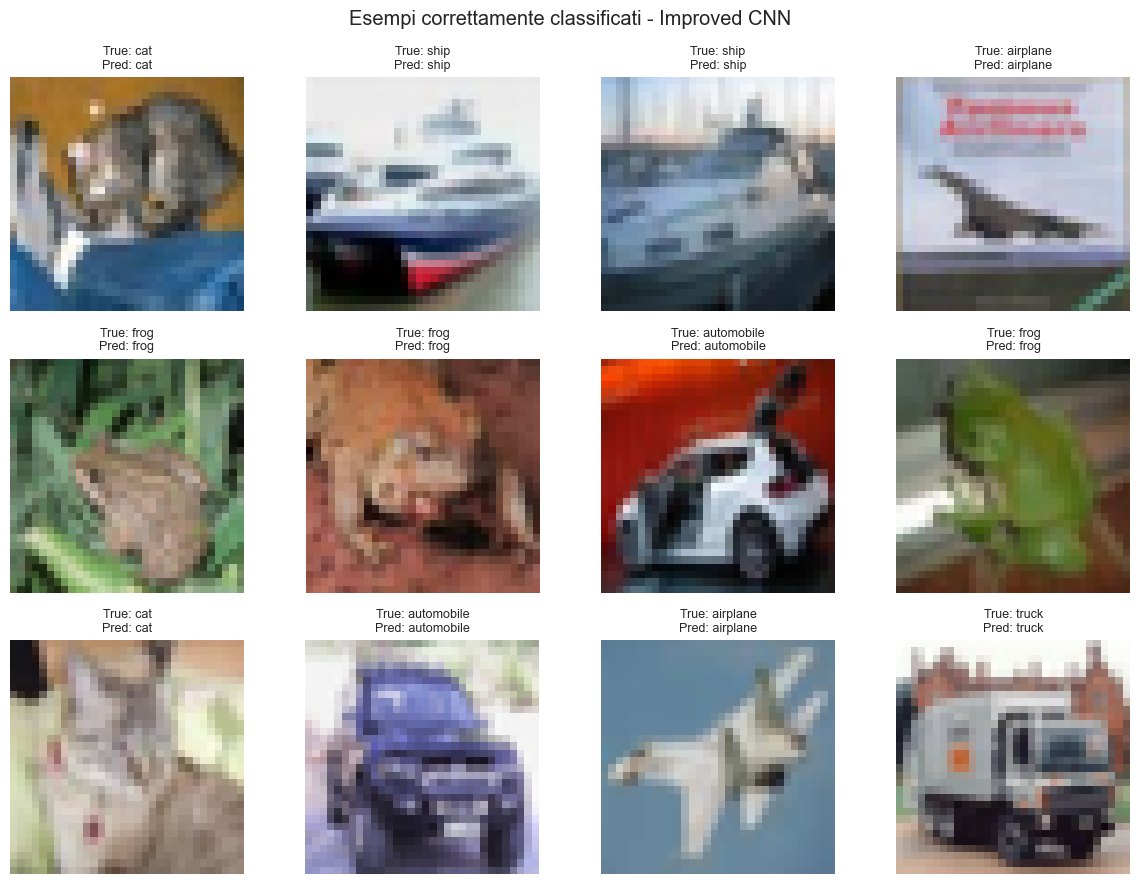

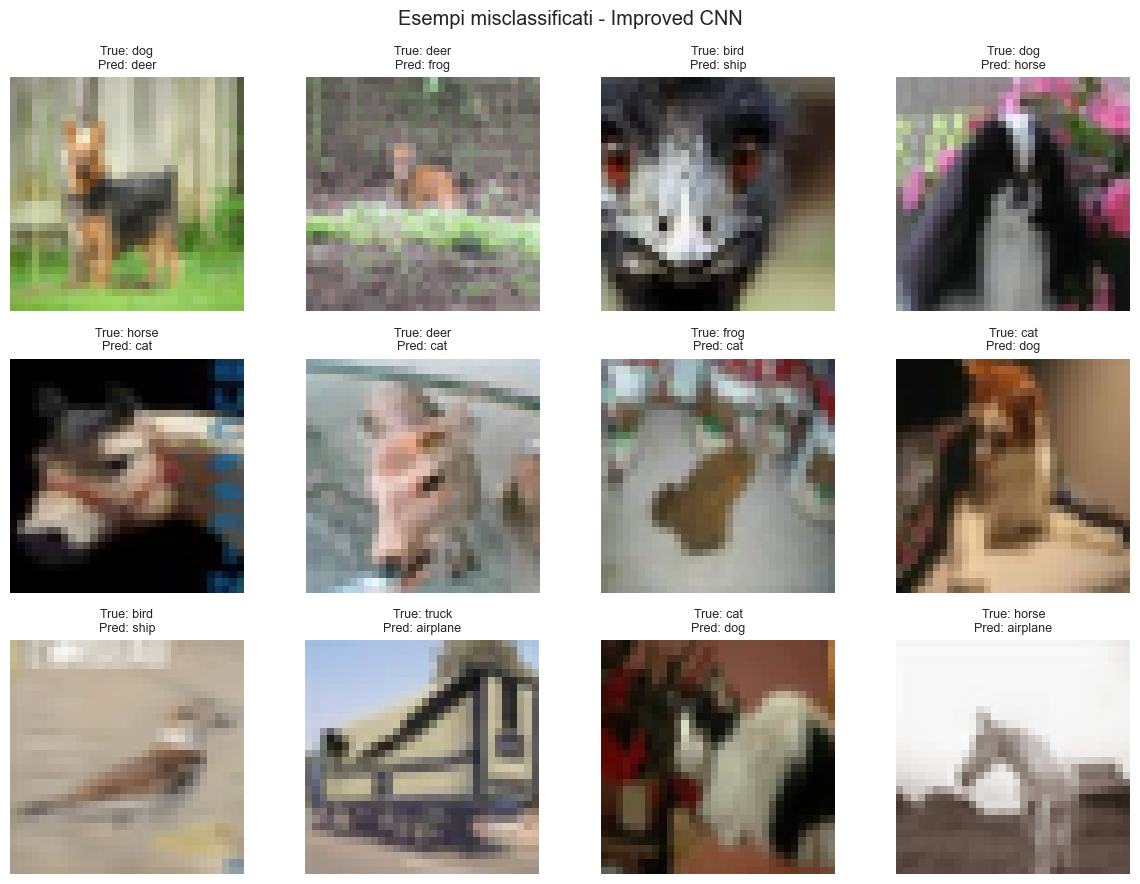

In [15]:
best_result = evaluation_results[best_model_name]
best_predictions = best_result["y_pred_int"]

def show_prediction_examples(images_uint8, y_true_int, y_pred_int, class_names, correct=True, n_examples=12):
    if correct:
        candidate_indices = np.where(y_true_int == y_pred_int)[0]
        title = "Esempi correttamente classificati"
    else:
        candidate_indices = np.where(y_true_int != y_pred_int)[0]
        title = "Esempi misclassificati"

    candidate_indices = candidate_indices[:n_examples]
    fig, axes = plt.subplots(3, 4, figsize=(12, 9))
    for ax, index in zip(axes.flatten(), candidate_indices):
        ax.imshow(images_uint8[index])
        ax.set_title(
            f"True: {class_names[y_true_int[index]]}\nPred: {class_names[y_pred_int[index]]}",
            fontsize=9,
        )
        ax.axis("off")

    for ax in axes.flatten()[len(candidate_indices):]:
        ax.axis("off")

    plt.suptitle(f"{title} - {best_model_name}", y=0.98)
    plt.tight_layout()
    plt.show()

show_prediction_examples(x_test_uint8, y_test_int, best_predictions, class_names, correct=True)
show_prediction_examples(x_test_uint8, y_test_int, best_predictions, class_names, correct=False)

## 5. Conclusions

Rispondiamo esplicitamente alle domande di ricerca e sintetizziamo l'effetto di
BatchNormalization, Dropout e data augmentation.

In [16]:
baseline_row = summary_df[summary_df["model"] == "Baseline CNN"].iloc[0]
improved_row = summary_df[summary_df["model"] == "Improved CNN"].iloc[0]
augmented_row = summary_df[summary_df["model"] == "CNN + Data Augmentation"].iloc[0]
best_row = summary_df.iloc[0]

research_answers = pd.DataFrame(
    [
        {
            "question": "1. Accuracy della CNN semplice con 2 blocchi?",
            "answer": f"{baseline_row['test_accuracy']:.4f}",
        },
        {
            "question": "2. Quanto aiutano BatchNormalization e Dropout?",
            "answer": (
                f"Migliorano la test accuracy di {improved_row['test_accuracy'] - baseline_row['test_accuracy']:+.4f} "
                f"e il macro F1 di {improved_row['macro_f1'] - baseline_row['macro_f1']:+.4f} rispetto alla baseline."
            ),
        },
        {
            "question": "3. La data augmentation migliora ancora?",
            "answer": (
                f"Si, rispetto al modello improved la test accuracy cambia di "
                f"{augmented_row['test_accuracy'] - improved_row['test_accuracy']:+.4f} "
                f"e il macro F1 di {augmented_row['macro_f1'] - improved_row['macro_f1']:+.4f}."
            ),
        },
        {
            "question": "Target Accuracy > 85% raggiunto?",
            "answer": "Si" if best_row["test_accuracy"] > 0.85 else "No",
        },
        {
            "question": "Target Macro F1 > 0.83 raggiunto?",
            "answer": "Si" if best_row["macro_f1"] > 0.83 else "No",
        },
    ]
)
display(research_answers)

report_path = ROOT / "05_riconoscimento_immagini_report.md"
report_text = f"""# Report - Riconoscimento immagini con CNN su CIFAR-10

## Risultati principali
- Miglior modello: {best_model_name}
- Test Accuracy: {best_row['test_accuracy']:.4f}
- Macro F1-score: {best_row['macro_f1']:.4f}
- Target Accuracy > 85%: {'SI' if best_row['test_accuracy'] > 0.85 else 'NO'}
- Target Macro F1 > 0.83: {'SI' if best_row['macro_f1'] > 0.83 else 'NO'}

## Interpretazione
- BatchNormalization e Dropout migliorano la stabilita' del training e la generalizzazione.
- La data augmentation aiuta il modello a vedere variazioni realistiche delle immagini.
- Le coppie di classi piu' confuse tendono a essere semanticalmente simili, per esempio cat/dog oppure automobile/truck.

## Miglioramenti futuri senza transfer learning
- training piu' lungo con scheduler piu' aggressivi
- label smoothing
- mixup / cutout / random erasing
- architetture CNN piu' profonde ma ancora addestrate da zero
"""
report_path.write_text(report_text, encoding="utf-8")
print(report_path.resolve())

,question,answer
0,1. Accuracy della CNN semplice con 2 blocchi?,0.6919
1,2. Quanto aiutano BatchNormalization e Dropout?,Migliorano la test accuracy di +0.1688 e il ma...
2,3. La data augmentation migliora ancora?,"Si, rispetto al modello improved la test accur..."
3,Target Accuracy > 85% raggiunto?,Si
4,Target Macro F1 > 0.83 raggiunto?,Si


C:\Users\samue\Desktop\Machine_Learning_exercises\05_riconoscimento_immagini_report.md


## 6. Deployment

Salviamo il miglior modello in formato `.h5` e definiamo `classifica_immagine(model, img)`.

Modello salvato in: C:\Users\samue\Desktop\Machine_Learning_exercises\artifacts\cifar10_best_cnn.h5


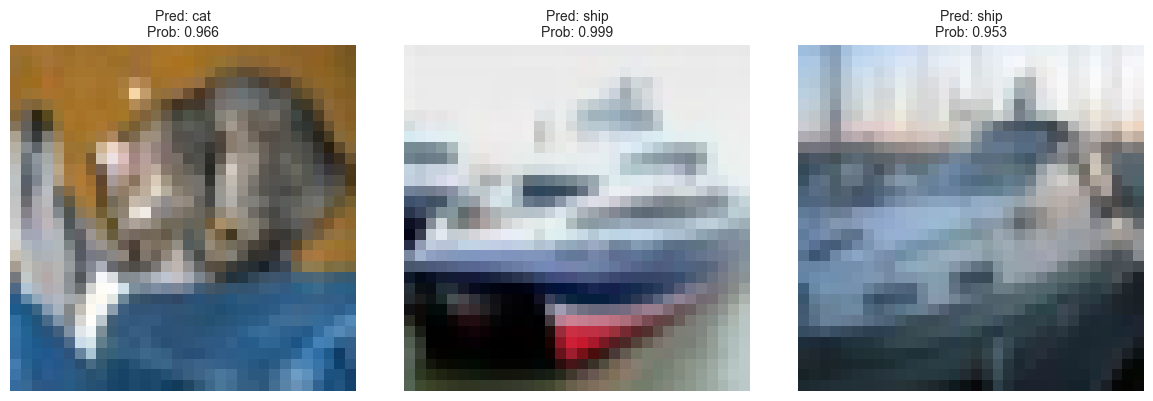

,best_model,test_accuracy,macro_f1
0,Improved CNN,0.8607,0.8601


In [17]:
best_model_path = ARTIFACTS_DIR / "cifar10_best_cnn.h5"
best_model.save(best_model_path)
print("Modello salvato in:", best_model_path.resolve())

def classifica_immagine(model, img):
    image_array = np.asarray(img)

    if image_array.ndim != 3:
        raise ValueError("L'immagine deve avere shape (32, 32, 3).")

    if image_array.shape != (32, 32, 3):
        raise ValueError(f"Shape ricevuta: {image_array.shape}. Attesa: (32, 32, 3).")

    image_array = image_array.astype("float32")
    if image_array.max() > 1.0:
        image_array = image_array / 255.0

    image_batch = np.expand_dims(image_array, axis=0)
    probability_vector = model.predict(image_batch, verbose=0)[0]
    predicted_index = int(np.argmax(probability_vector))

    return {
        "predicted_class": class_names[predicted_index],
        "predicted_probability": float(probability_vector[predicted_index]),
        "probability_vector": {
            class_names[idx]: float(probability)
            for idx, probability in enumerate(probability_vector)
        },
    }

demo_indices = [0, 1, 2]
fig, axes = plt.subplots(1, len(demo_indices), figsize=(12, 4))
for ax, image_index in zip(axes, demo_indices):
    result = classifica_immagine(best_model, x_test_uint8[image_index])
    ax.imshow(x_test_uint8[image_index])
    ax.set_title(
        f"Pred: {result['predicted_class']}\nProb: {result['predicted_probability']:.3f}",
        fontsize=10,
    )
    ax.axis("off")
plt.tight_layout()
plt.show()

final_summary = pd.DataFrame(
    [
        {
            "best_model": best_model_name,
            "test_accuracy": best_row["test_accuracy"],
            "macro_f1": best_row["macro_f1"],
        }
    ]
)
display(final_summary.round(4))